In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df['director'] = df['director'].fillna('Not Available')
df['cast'] = df['cast'].fillna('Not Available')

In [8]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
description       0
dtype: int64

In [9]:
df[df['duration'].isnull()][['title','rating','duration']]

,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [10]:
mask = df['duration'].isnull()
df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = np.nan
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [11]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         831
date_added       10
release_year      0
rating            0
duration          0
listed_in         0
description       0
dtype: int64

In [12]:
df['date_added'] = df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year
df.dropna(subset=['date_added'], inplace=True)

In [13]:
df.isnull().sum()

show_id           0
type              0
title             0
director          0
cast              0
country         830
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added        0
dtype: int64

In [14]:
df['main_country'] = (
    df['country']
    .fillna('Unknown')
    .str.split(',')
    .str[0]
)

In [15]:
df['main_genre']=(
    df['listed_in'].str.split(',').str[0]
)

# Exploratory Data Analyis

## Movies vs TV Shows

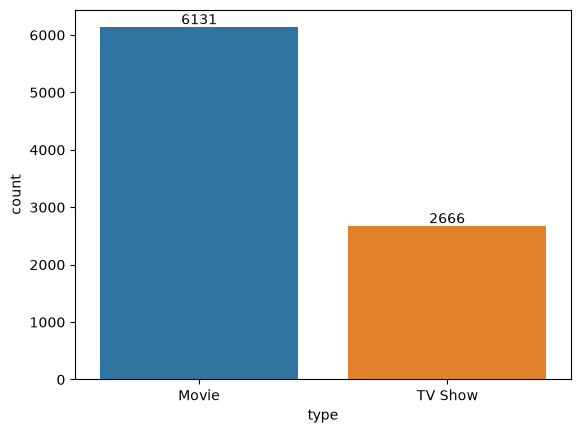

In [16]:
ax=sns.countplot(data=df, x='type', hue='type')
for bars in ax.containers:
    ax.bar_label(bars)

Netflix has significantly more Movies than TV Shows


## Content Added Per Year

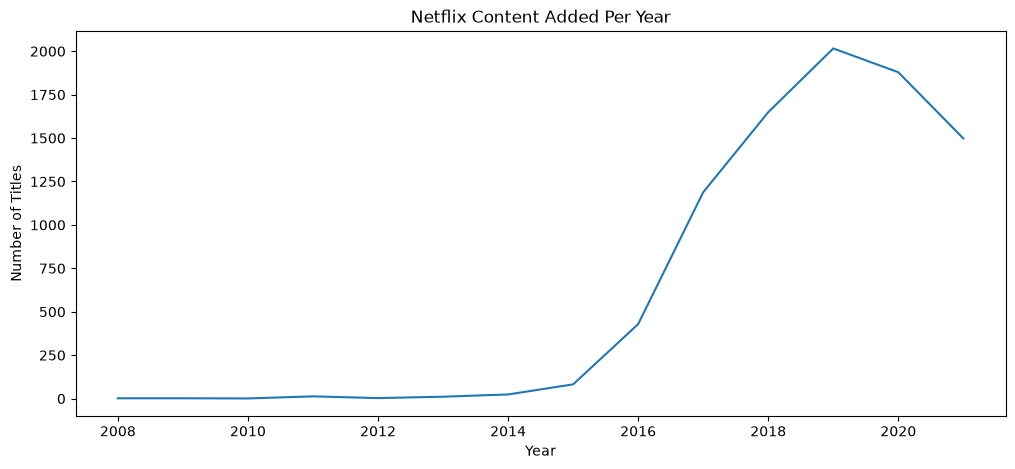

In [17]:
year_data = df['year_added'].value_counts().sort_index()
year_data.plot(kind='line', figsize=(12,5))
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.title("Netflix Content Added Per Year")
plt.show()


Most content was added during 2018–2020


## Top 10 countires

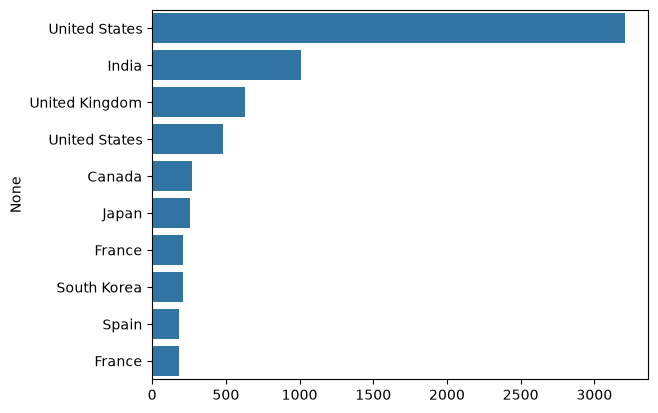

In [18]:
country_series = df['country'].str.split(',', expand=True).stack()
top_countries = country_series.value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.show()


US and India contribute major content


## Most Common Ratings

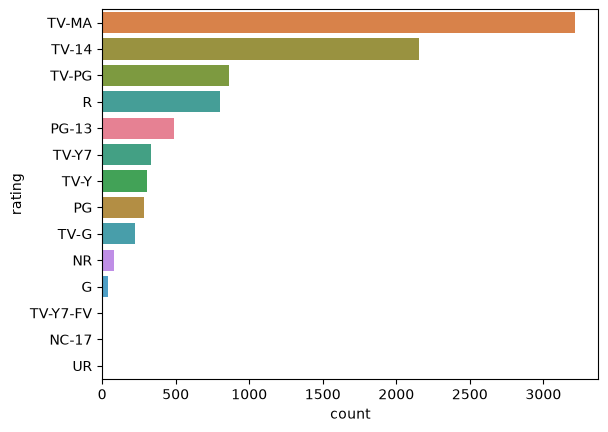

In [19]:
sns.countplot(data=df, y=df['rating'],
              order=df['rating'].value_counts().index,hue='rating')
plt.show()


Netflix strongly focuses on teen and adult audiences

## Popular Genres

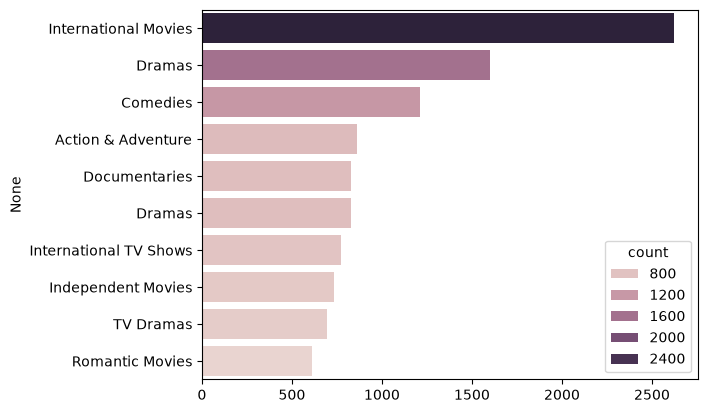

In [20]:
genre = df['listed_in'].str.split(',', expand=True).stack()
genre_counts = genre.value_counts().head(10)
sns.barplot(x=genre_counts.values, y=genre_counts.index,hue=genre_counts)
plt.show()


Drama and International Movies dominate


## Final Conclusion

The analysis shows that Netflix has significantly more Movies than TV Shows, with major content growth during 2018–2020. Most content is rated TV-MA and TV-14, indicating a strong focus on teen and adult audiences. Drama, International Movies, and Comedy are the most popular genres, while the United States and India contribute the highest content volume, highlighting Netflix’s strong global presence and diverse content strategy.

## Connection with Database to perform queries

In [21]:
from sqlalchemy import create_engine

#mysql connection
username='root'
passw='password'
host='127.0.0.1'
port='3306'
database='netflix_analysis'

engine=create_engine(f"mysql+pymysql://{username}:{passw}@{host}:{port}/{database}")

table_name='netflixtable'
df.to_sql(table_name,engine, if_exists='replace', index=False)

8797